# Test conversion of file to npz
## We also included there violin plots for comparing conditions in this test

In [1]:
from metamers.eeg.ssvep2python import transform1Set, load_ssvep_npz
import os
srcFolder = "/mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/eegExp/results/shareDarren"
fname    = "MET000TESTBLUEBlueTest.mat"
targetFoder = "/home/zevaz/projects/metamers/eeg/ssvepBLUETEST"
transform1Set(mat_root=srcFolder, fname= fname, npz_root=targetFoder)

[convert] MET000TESTBLUEBlueTest.mat → /home/zevaz/projects/metamers/eeg/ssvepBLUETEST/MET000TESTBLUEBlueTest.npz
Saved fields:
['SSVEPs', 'SubID', 'baselineDIM', 'baselines', 'blueArray', 'blueFixed', 'blueShiftArray', 'conditions', 'redFixed', 'ssvepDIM', 'yellowFixed']
Conversion complete.


## Load npz file

In [2]:
npz_path = os.path.join(targetFoder, fname.replace(".mat", ".npz"))
ssvep =load_ssvep_npz(npz_path)
print(ssvep)


{'SSVEPs': array([[0.57458199, 1.68615259, 1.38617735, 1.3971669 , 1.276222  ,
        0.63657291, 1.60777682, 1.41036079, 1.47699595, 0.88170273],
       [1.01108428, 1.83785762, 1.56012259, 1.41474969, 1.19273821,
        0.64286751, 1.64370139, 1.32759364, 1.23478966, 0.99365413],
       [1.21102543, 1.74981003, 1.73566425, 1.19934757, 0.83571819,
        0.7937247 , 1.66313401, 1.55194539, 1.29947418, 1.09757947],
       [1.33810631, 1.18173943, 1.47208709, 1.11573053, 0.82034508,
        0.78143424, 1.72465851, 1.67960226, 1.01057793, 0.92517417],
       [1.27404066, 1.22642626, 1.4937425 , 1.24979584, 0.86055625,
        0.81367079, 1.70643762, 1.44127808, 0.98134406, 1.02347939],
       [1.15233331, 1.26114237, 1.56537912, 1.05311463, 0.89621492,
        1.08307232, 1.77514872, 1.5249654 , 0.89059631, 1.0909456 ],
       [1.48669497, 1.26148447, 1.53372137, 0.78664293, 1.09101991,
        0.89673433, 1.76474707, 1.50723977, 0.8414557 , 0.75331877],
       [1.31147552, 1.29552371

In [3]:
print(type(ssvep))
print(isinstance(ssvep, dict))
print(ssvep.keys())
# inspect the elements
for k in ssvep.keys():
    print(k, type(ssvep[k]), getattr(ssvep[k],'shape',None))

<class 'dict'>
True
dict_keys(['SSVEPs', 'SubID', 'baselineDIM', 'baselines', 'blueArray', 'blueFixed', 'blueShiftArray', 'conditions', 'redFixed', 'ssvepDIM', 'yellowFixed'])
SSVEPs <class 'numpy.ndarray'> (20, 10)
SubID <class 'numpy.ndarray'> (1,)
baselineDIM <class 'numpy.ndarray'> (1, 1)
baselines <class 'numpy.ndarray'> (3, 10)
blueArray <class 'numpy.ndarray'> (1, 20)
blueFixed <class 'numpy.ndarray'> (1, 1)
blueShiftArray <class 'numpy.ndarray'> (1, 20)
conditions <class 'numpy.ndarray'> (1, 10)
redFixed <class 'numpy.ndarray'> (1, 1)
ssvepDIM <class 'numpy.ndarray'> (1, 1)
yellowFixed <class 'numpy.ndarray'> (1, 1)


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd

def convert_to_dataframe(data = ssvep):
    ssvep_vals = data["SSVEPs"]        # shape (20, 10)
    baseline_vals = data["baselines"]  # shape (3, 10)
    raw_conditions = [str(c) for c in data["conditions"].flatten()]
    conditions = [ c.strip("[]'")  for c in raw_conditions]
    # Build long-form dataframe
    rows = []

    # Add SSVEP rows
    for cond_idx, cond in enumerate(conditions):
        for v in ssvep_vals[:, cond_idx]:
            rows.append({"Condition": cond, "Value": v, "Type": "SSVEP"})

    # Add baseline rows
    for cond_idx, cond in enumerate(conditions):
        for v in baseline_vals[:, cond_idx]:
            rows.append({"Condition": cond, "Value": v, "Type": "Baseline"})

    df = pd.DataFrame(rows)
    return df


def plot1variable(data , var= "Value", title=""):

    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=data,
        x="Condition",
        y=var,
        hue="Type",
        split=True,
        inner="quartile",
        palette=["#1f77b4", "#ff7f0e"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plotFilterVsnoFilter(dataFiltered, dataNofiltered,var="Value", mode = "All" ,title="SSVEP Amplitudes: Filter vs NoFilter per Condition"):
    # correspondence dictionary
    filter_map = {
    "BFi": "B",
    "BYFi": "BY",
    "BRFi": "BR",
    "BFFi": "BF",
    "BSFi": "BS"
    }

    # Add a base condition for no filteredData
    dataNofiltered = dataNofiltered.copy()
    dataNofiltered["BaseCondition"] = dataNofiltered["Condition"]  # already base
    dataNofiltered["FilterType"] = "NoFilter"

    # Add a base condition for Filtered data
    dataFiltered = dataFiltered.copy()
    dataFiltered["BaseCondition"] = dataFiltered["Condition"].map(filter_map)
    dataFiltered["FilterType"] = "Filter"

    # combine the patched datasets
    dfCompare = pd.concat([dataNofiltered, dataFiltered], ignore_index=True)

        # -------------------------
    # Apply mode filtering here
    # -------------------------
    if mode.lower() == "ssvep":
        dfCompare = dfCompare[dfCompare["Type"] == "SSVEP"]
    elif mode.lower() == "baseline":
        dfCompare = dfCompare[dfCompare["Type"] == "Baseline"]
    # mode="all" → no filtering
    
    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=dfCompare,
        x="BaseCondition",
        y=var,
        hue="FilterType",
        split=True,
        inner="quartile",
        palette=["#1f77b4", "#ff7f0e"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()



    Condition     Value      Type
0           B  0.574582     SSVEP
1           B  1.011084     SSVEP
2           B  1.211025     SSVEP
3           B  1.338106     SSVEP
4           B  1.274041     SSVEP
..        ...       ...       ...
225      BFFi  0.529291  Baseline
226      BFFi  0.703326  Baseline
227      BSFi  0.780674  Baseline
228      BSFi  0.633201  Baseline
229      BSFi  0.711151  Baseline

[230 rows x 3 columns]


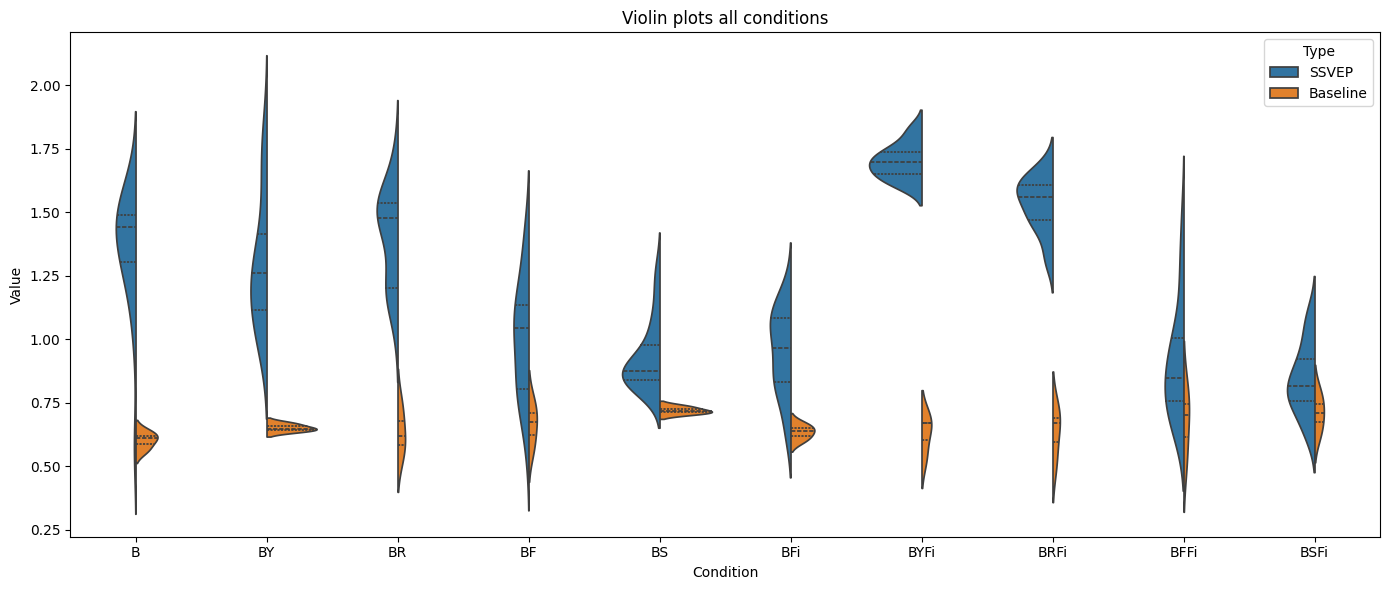

In [5]:
df = convert_to_dataframe(ssvep)
print(df)
plot1variable(df,"Value","Violin plots all conditions")

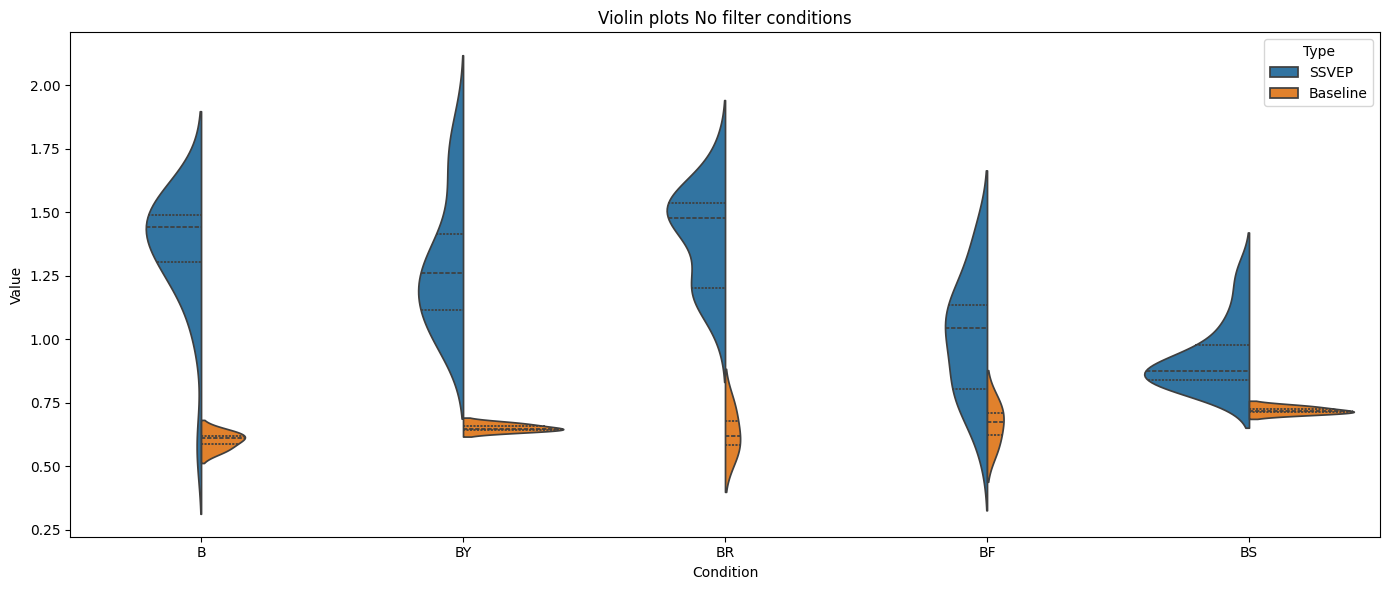

In [6]:
dfnoFilt = df[df["Condition"].isin(['B', 'BY', 'BR', 'BF', 'BS'])]
plot1variable(dfnoFilt,"Value","Violin plots No filter conditions")

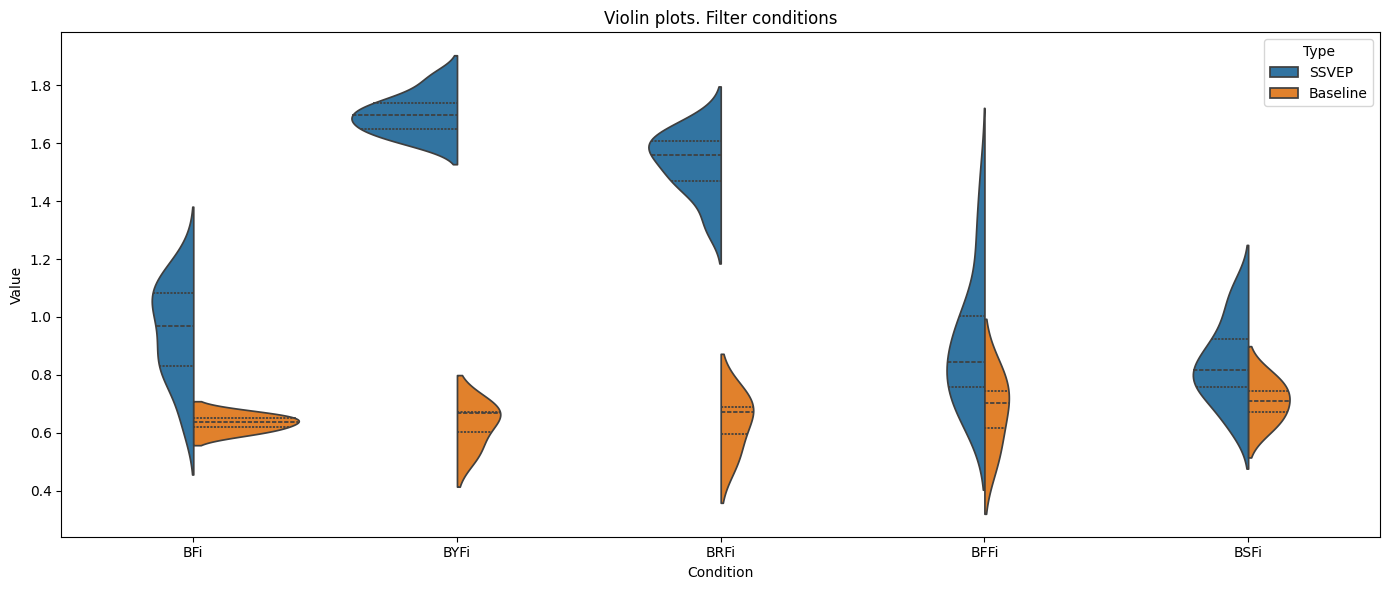

In [7]:
dfFilt = df[df["Condition"].isin(['BFi', 'BYFi', 'BRFi', 'BFFi', 'BSFi'])]
plot1variable(dfFilt,"Value","Violin plots. Filter conditions")

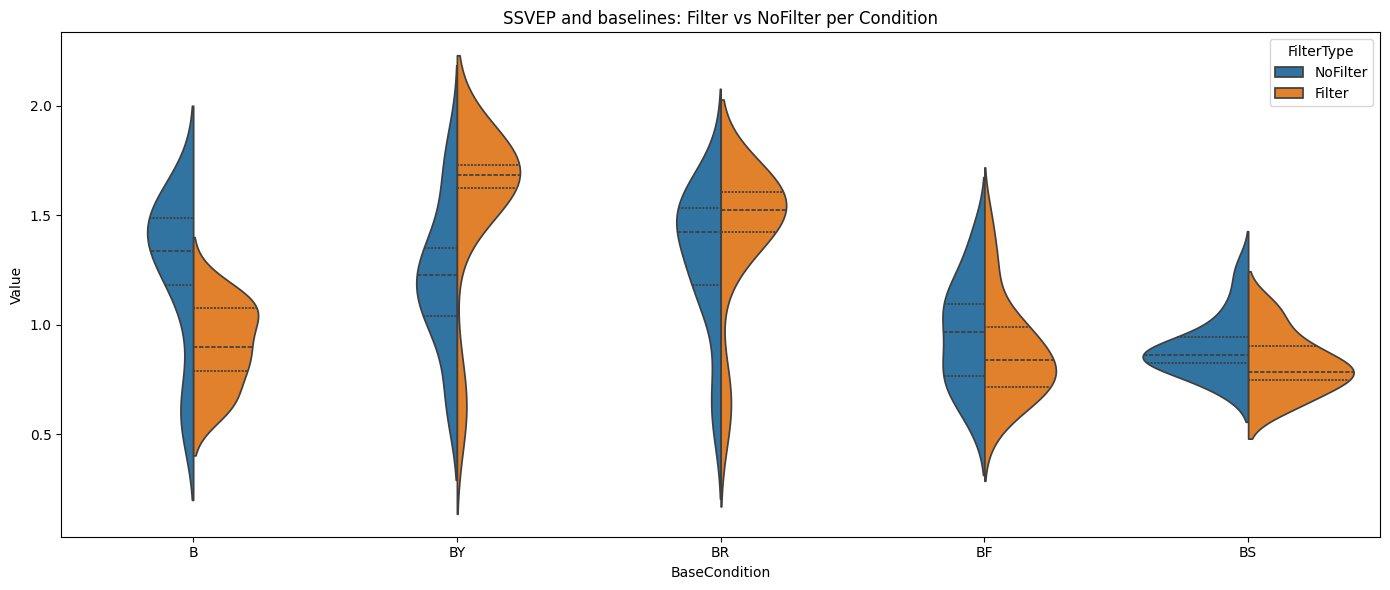

In [8]:
plotFilterVsnoFilter(dfFilt, dfnoFilt,var="Value",mode="All",title="SSVEP and baselines: Filter vs NoFilter per Condition")

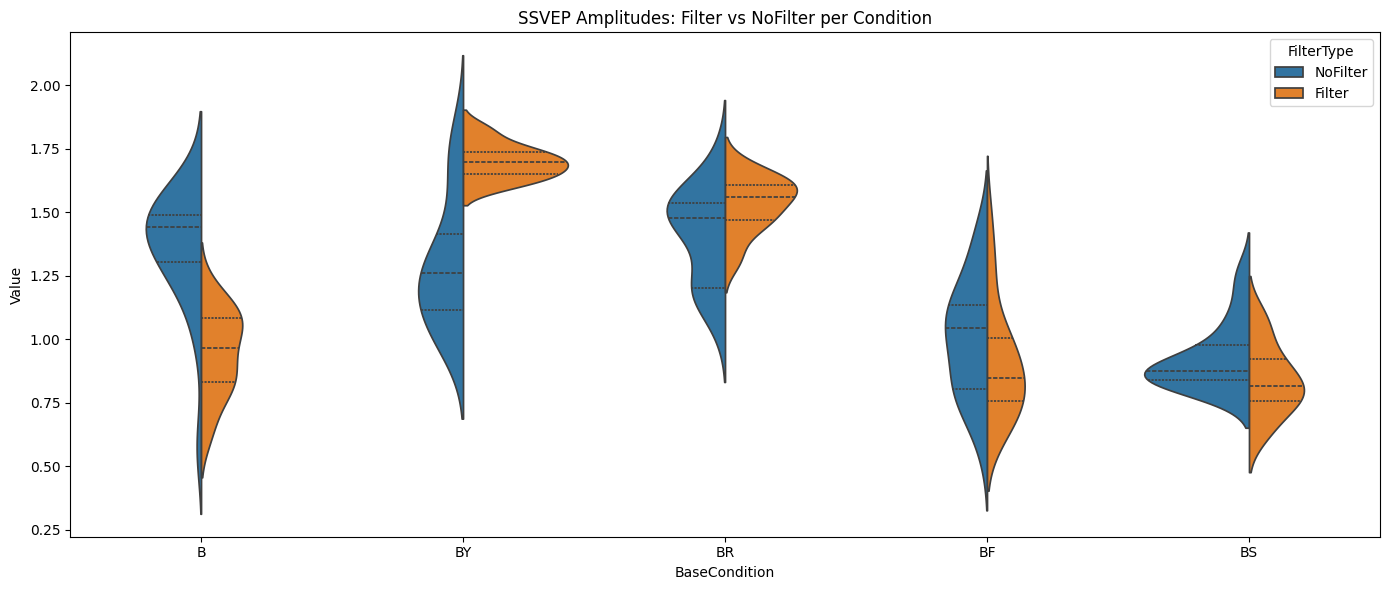

In [9]:
plotFilterVsnoFilter(dfFilt, dfnoFilt,var="Value",mode="ssvep" ,title="SSVEP Amplitudes: Filter vs NoFilter per Condition")

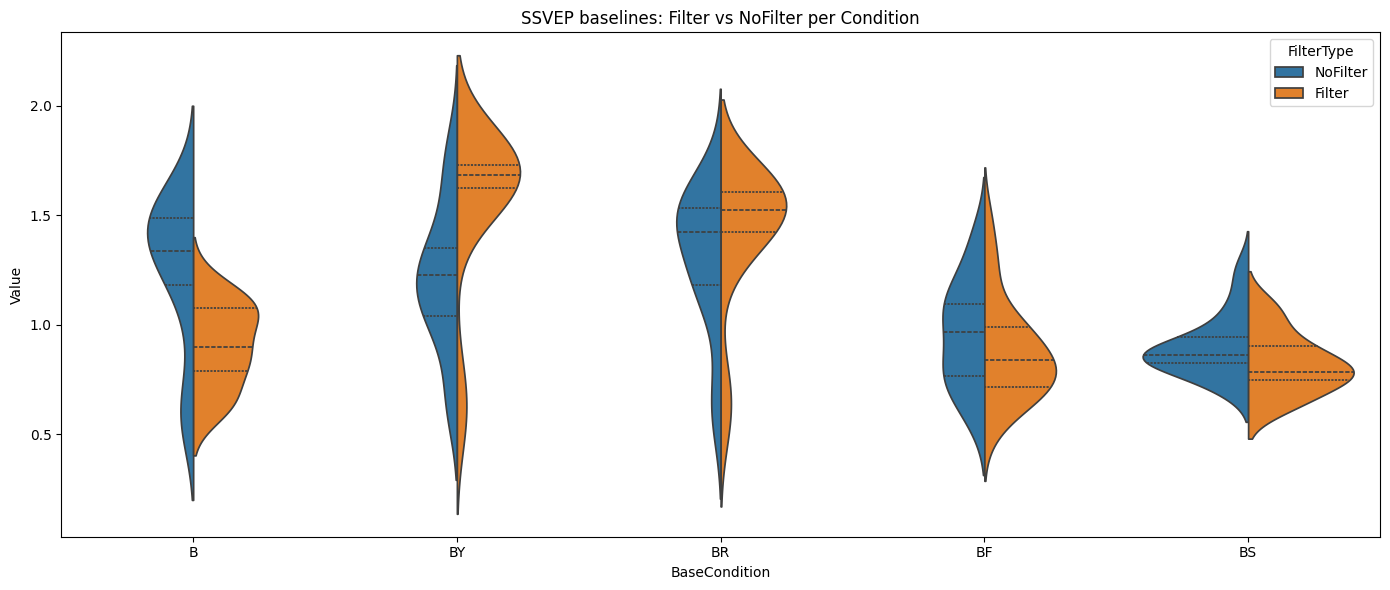

In [10]:
plotFilterVsnoFilter(dfFilt, dfnoFilt,var="Value",mode="baselines" ,title="SSVEP baselines: Filter vs NoFilter per Condition")